<a href="https://colab.research.google.com/github/HitenBangarwa/HitenMLlab/blob/main/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import SpectralClustering

%matplotlib inline

In [ ]:
!pip install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind")

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 497k/497k [00:00<00:00, 47.1MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind/versions/2
/root/.cache/kagglehub/datasets/anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind/versions/2/test.csv
/root/.cache/kagglehub/datasets/anantsakhare/rental-price-of-indias-it-capital-pune-mh-ind/versions/2/train.csv


In [ ]:
# Replace filename if needed
file_path = os.path.join(path, "train.csv")

df = pd.read_csv(file_path)

df.head()

,bedroom,bathrooms,area,furnishing,avalable_for,address,floor_number,facing,floor_type,gate_community,...,pooja_room,study_room,others,servant_room,store_room,maintenance_amt,brok_amt,deposit_amt,mnt_amt,rent
0,2,2,1050.0,Unfurnished,All,"Sadguru hights, Pingale Wasti, , Pune, Maharas...",5,West,Marble,Yes,...,0,0,0,0,0,0,0,3,0.0,20000.0
1,2,2,760.0,Unfurnished,All,"Manav Silver Springs, Wagholi, , Pune, Maharas...",5,East,Vitrified,Yes,...,0,0,0,0,0,0,0,40000,0.0,14000.0
2,3,3,0.0,Semifurnished,All,"Saarrthi Souvenir, Mahalunge, , Pune, Maharashtra",1,South-West,Vitrified,Yes,...,0,0,1,0,0,Maintenance 1/ (/ month,23000,60000,1.0,22999.0
3,1,1,628.0,Furnished,Family Only,"Dhan Residency, Wanowrie, , Pune, Maharashtra",3,East,Mosaic,Yes,...,0,0,0,0,0,0,0,40000,0.0,13000.0
4,2,2,668.0,Semifurnished,"Family , Bachelors (Men Only)","Saptsiddhi Savali Homes, Uruli Devachi, , Pune...",6,South,Polished concrete,Yes,...,0,0,0,0,0,0,0,20,0.0,7500.0


In [ ]:
# Select only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Handle missing values
df_numeric = df_numeric.fillna(0)

df_numeric.head()

,bedroom,bathrooms,area,floor_number,parking,aggDur,noticeDur,lightbill,powerbackup,no_room,pooja_room,study_room,others,servant_room,store_room,brok_amt,deposit_amt,mnt_amt,rent
0,2,2,1050.0,5,0,11,2,0,2,1,0,0,0,0,0,0,3,0.0,20000.0
1,2,2,760.0,5,2,11,1,0,2,1,0,0,0,0,0,0,40000,0.0,14000.0
2,3,3,0.0,1,1,11,1,0,2,0,0,0,1,0,0,23000,60000,1.0,22999.0
3,1,1,628.0,3,1,11,1,0,0,1,0,0,0,0,0,0,40000,0.0,13000.0
4,2,2,668.0,6,1,12,1,1,1,1,0,0,0,0,0,0,20,0.0,7500.0


In [ ]:
X = df_numeric.values

print("Shape of dataset:", X.shape)

Shape of dataset: (10884, 19)


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

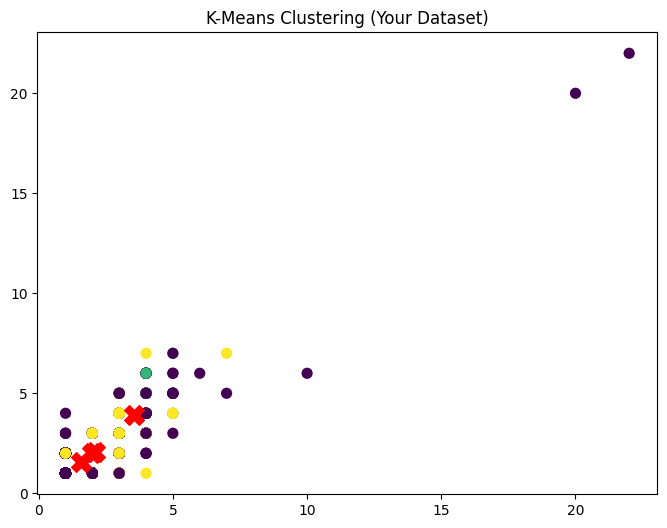

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1],
            c='red', s=200, marker='X')

plt.title("K-Means Clustering (Your Dataset)")
plt.show()

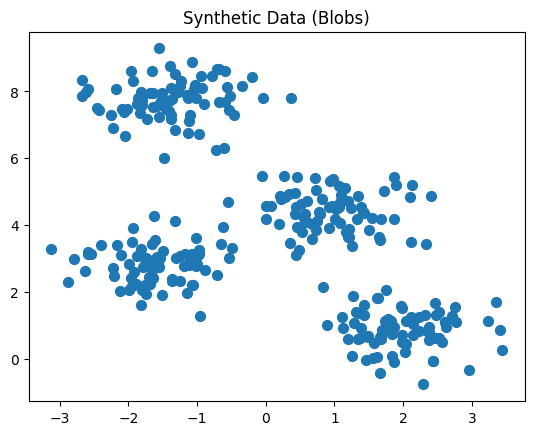

In [ ]:
X_blob, y_blob = make_blobs(n_samples=300, centers=4,
                           cluster_std=0.60, random_state=0)

plt.scatter(X_blob[:, 0], X_blob[:, 1], s=50)
plt.title("Synthetic Data (Blobs)")
plt.show()

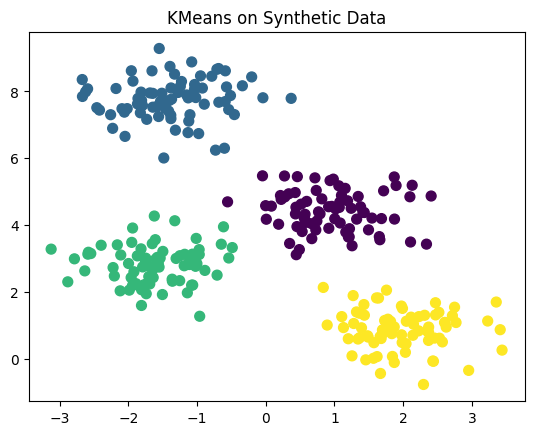

In [ ]:
kmeans_blob = KMeans(n_clusters=4)

labels_blob = kmeans_blob.fit_predict(X_blob)

plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels_blob,
            s=50, cmap='viridis')

plt.title("KMeans on Synthetic Data")
plt.show()

In [ ]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        labels = pairwise_distances_argmin(X, centers)

        new_centers = np.array([
            X[labels == i].mean(0)
            for i in range(n_clusters)
        ])

        if np.all(centers == new_centers):
            break

        centers = new_centers

    return centers, labels

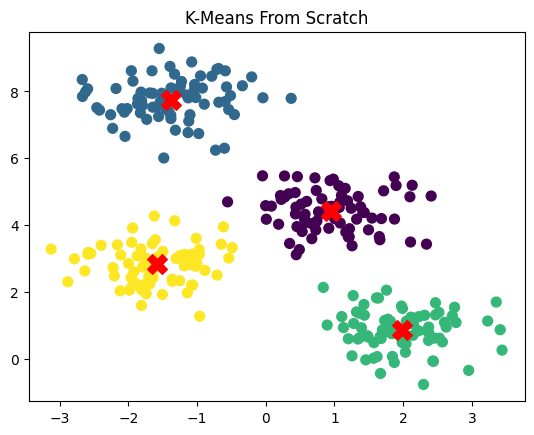

In [ ]:
centers_custom, labels_custom = find_clusters(X_blob, 4)

plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels_custom,
            s=50, cmap='viridis')

plt.scatter(centers_custom[:, 0], centers_custom[:, 1],
            c='red', s=200, marker='X')

plt.title("K-Means From Scratch")
plt.show()

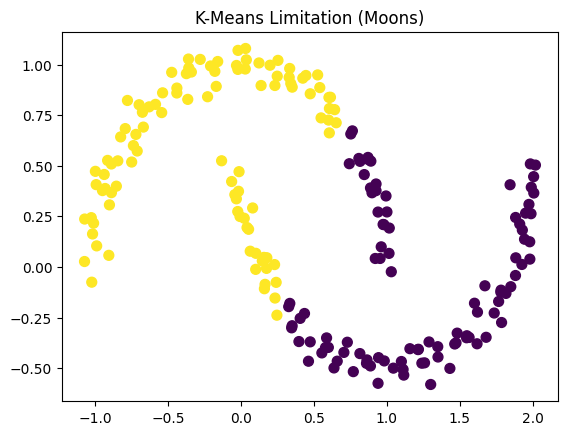

In [ ]:
X_moon, y_moon = make_moons(200, noise=0.05, random_state=0)

labels_moon = KMeans(2).fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_moon,
            s=50, cmap='viridis')

plt.title("K-Means Limitation (Moons)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


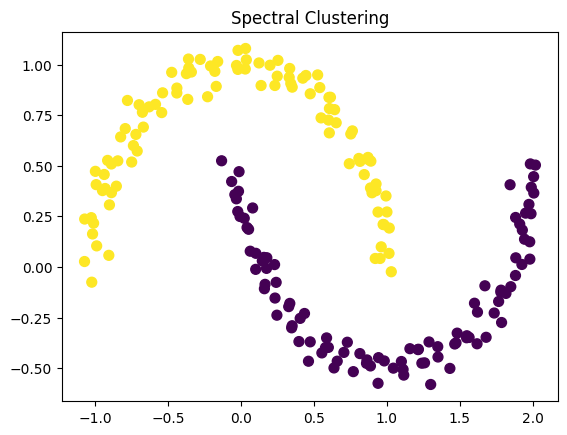

In [ ]:
model = SpectralClustering(n_clusters=2,
                           affinity='nearest_neighbors',
                           assign_labels='kmeans')

labels_spec = model.fit_predict(X_moon)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_spec,
            s=50, cmap='viridis')

plt.title("Spectral Clustering")
plt.show()